# Guardian SVD Exploration

This notebook explores the truncated-SVD representation for the Guardian opinion dataset using the backend utilities already built in this repo.

It mirrors the classroom SVD demo, but on this project's own article corpus.

What it covers:
- building or loading an SVD index for the Guardian dataset
- plotting singular values and cumulative explained variance
- inspecting the top terms for latent dimensions
- projecting queries into latent space and examining their top dimensions
- comparing raw TF-IDF search against truncated-SVD search
- exploring nearest articles in latent space


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (path / 'backend').exists() and (path / 'data').exists()
    ),
    Path.cwd().resolve(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.services.retrieval_service import tfidf_cos_search
from backend.text_processing.svd_processor import (
    DEFAULT_INDEX_DIR,
    DEFAULT_SVD_INDEX_NAME,
    DEFAULT_SVD_N_COMPONENTS,
    load_svd_index,
    preprocess_svd_index,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 140)
PROJECT_ROOT


/Users/stevenzhou/miniconda3/envs/info4300/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


PosixPath('/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear')

In [2]:
YEARS = list(range(2015, 2026))
N_COMPONENTS = 100
INDEX_DIR = DEFAULT_INDEX_DIR
INDEX_NAME = DEFAULT_SVD_INDEX_NAME
FORCE_REBUILD = False
VECTORIZER_PARAMS = None
# VECTORIZER_PARAMS = {'ngram_range': (1, 2)}

TOP_N = 8
QUERY = 'climate migration labor rights'
TITLE_QUERY = 'climate'
DIMENSIONS_TO_INSPECT = list(range(10))
TOP_TERMS_PER_DIMENSION = 10
ALL_DIMENSIONS_SUMMARY_EXPORT_PATH = (
    PROJECT_ROOT / 'data' / 'processed' / 'analysis_exports'
    / f'{INDEX_NAME}_all_dimensions_summary.csv'
)

print(f'YEARS: {YEARS[0]}-{YEARS[-1]}')
print(f'N_COMPONENTS: {N_COMPONENTS}')
print(f'INDEX_NAME: {INDEX_NAME}')
print(f'INDEX_DIR: {INDEX_DIR}')
print(f'VECTORIZER_PARAMS: {VECTORIZER_PARAMS}')
print(f'ALL_DIMENSIONS_SUMMARY_EXPORT_PATH: {ALL_DIMENSIONS_SUMMARY_EXPORT_PATH}')


YEARS: 2015-2025
N_COMPONENTS: 100
INDEX_NAME: guardian_tfidf_svd
INDEX_DIR: /Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index
VECTORIZER_PARAMS: None
ALL_DIMENSIONS_SUMMARY_EXPORT_PATH: /Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/analysis_exports/guardian_tfidf_svd_all_dimensions_summary.csv


In [3]:
build_result = preprocess_svd_index(
    index_dir=INDEX_DIR,
    index_name=INDEX_NAME,
    years=YEARS,
    n_components=N_COMPONENTS,
    vectorizer_params=VECTORIZER_PARAMS,
    force_rebuild=FORCE_REBUILD,
)
build_result


{'built': False,
 'reason': 'up_to_date',
 'db_row_count': 66331,
 'index_dir': '/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index',
 'index_name': 'guardian_tfidf_svd'}

In [4]:
svd_index, svd_meta = load_svd_index(
    index_dir=INDEX_DIR,
    index_name=INDEX_NAME,
    load_articles=True,
)
diagnostics = svd_index.diagnostics()
articles = svd_index.articles.copy()

print(f"Loaded SVD index '{INDEX_NAME}'")
print(f"Documents: {diagnostics['n_docs']:,}")
print(f"Terms: {diagnostics['n_terms']:,}")
print(f"Effective dimensions: {diagnostics['n_components']}")
print(f"Requested dimensions: {diagnostics['requested_n_components']}")
print(f"Explained variance ratio sum: {diagnostics['explained_variance_ratio_sum']:.4f}")

articles[['id', 'title', 'year']].head(10)


Loaded SVD index 'guardian_tfidf_svd'
Documents: 66,331
Terms: 82,749
Effective dimensions: 100
Requested dimensions: 100
Explained variance ratio sum: 0.1317


,id,title,year
0,commentisfree/2015/jan/01/challenge-to-old-order-growing,"All over the world, the challenge to the old order is growing",2015
1,commentisfree/2015/jan/01/surveillance-2015-everything-play-for,"When it comes to surveillance, there is everything to play for",2015
2,commentisfree/2015/jan/01/sleep-new-years-resolution-success,Sleep your way to new year’s resolution success,2015
3,commentisfree/2015/jan/01/2015-general-election-russell-brand-revolution-young-people-vote,If the 2015 general election will be your first – this is your moment,2015
4,commentisfree/2015/jan/01/new-year-political-messages,New year: the season for grandstanding,2015
5,commentisfree/oliver-burkeman-column/2015/jan/01/detoxing-debunked,'Detoxing' has been debunked. Maybe it's time to debunk that,2015
6,commentisfree/2015/jan/01/write-about-who-you-are-not-who-you-want-to-become,"A letter to myself: Write about who you are, not who you want to become",2015
7,commentisfree/2015/jan/01/dear-tony-blair-electorate-shifted-left-ed-miliband,"Dear Tony Blair, maybe it’s your fault if the electorate hasn’t shifted to the left",2015
8,commentisfree/2015/jan/01/serial-adnan-syed-exonerated-new-trial,Will Serial's Adnan Syed ever be exonerated or get a new trial?,2015
9,commentisfree/2015/jan/01/diet-advice-fat-gp,Why not take diet advice from a fat GP? They’re only human,2015


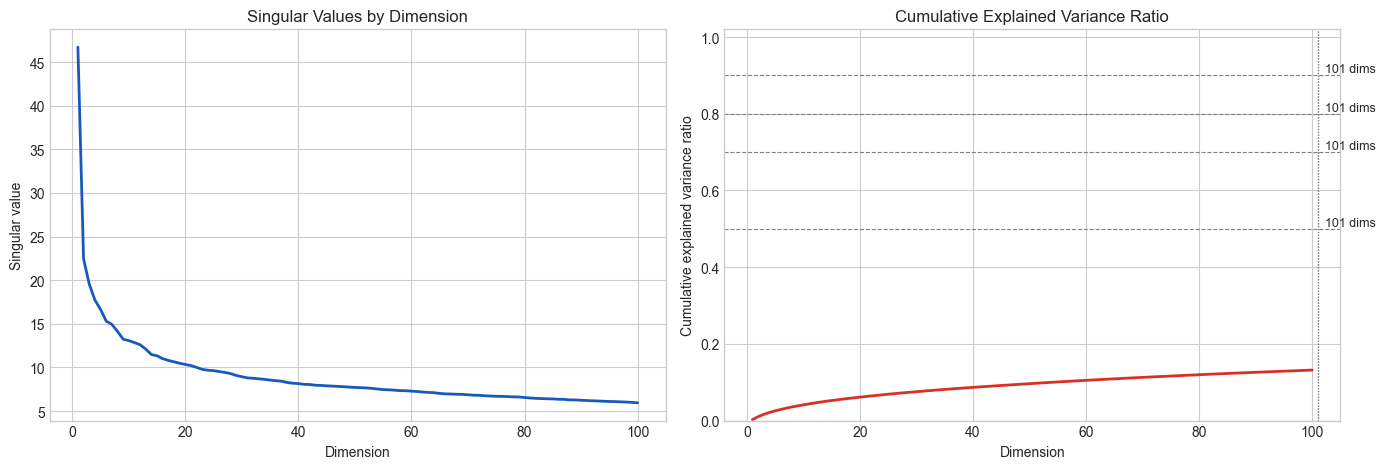

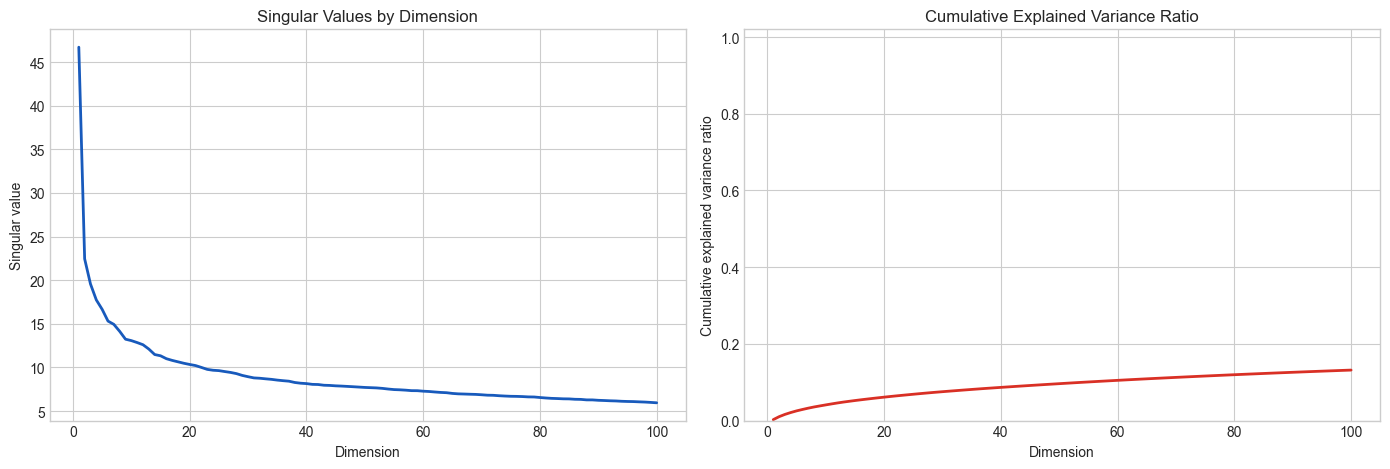

50% cumulative variance -> dimension 101 (dimension_index 100)
70% cumulative variance -> dimension 101 (dimension_index 100)
80% cumulative variance -> dimension 101 (dimension_index 100)
90% cumulative variance -> dimension 101 (dimension_index 100)


,dimension_index,dimension_label,singular_value,explained_variance_ratio,cumulative_explained_variance_ratio
0,0,1,46.709400,0.002464,0.002464
1,1,2,22.449013,0.007687,0.010151
2,2,3,19.568083,0.005955,0.016106
3,3,4,17.740202,0.004894,0.021000
4,4,5,16.659870,0.004311,0.025311
5,5,6,15.316582,0.003649,0.028959
6,6,7,14.939587,0.003464,0.032424
7,7,8,14.141124,0.003108,0.035532
8,8,9,13.239304,0.002725,0.038257
9,9,10,13.076514,0.002659,0.040916


In [6]:
diagnostics_df = pd.DataFrame({
    'dimension_index': np.arange(diagnostics['n_components']),
    'dimension_label': np.arange(1, diagnostics['n_components'] + 1),
    'singular_value': diagnostics['singular_values'],
    'explained_variance_ratio': diagnostics['explained_variance_ratio'],
    'cumulative_explained_variance_ratio': diagnostics['cumulative_explained_variance_ratio'],
})

thresholds = (0.5, 0.7, 0.8, 0.9)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(
    diagnostics_df['dimension_label'],
    diagnostics_df['singular_value'],
    linewidth=2,
    color='#185abc',
)
axes[0].set_title('Singular Values by Dimension')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Singular value')

axes[1].plot(
    diagnostics_df['dimension_label'],
    diagnostics_df['cumulative_explained_variance_ratio'],
    linewidth=2,
    color='#d93025',
)
for threshold in thresholds:
    dims_needed = int(
        np.searchsorted(
            diagnostics_df['cumulative_explained_variance_ratio'].to_numpy(),
            threshold,
        ) + 1
    )
    axes[1].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)
    axes[1].axvline(dims_needed, color='gray', linestyle=':', linewidth=0.8)
    axes[1].text(dims_needed, threshold, f'  {dims_needed} dims', va='bottom', fontsize=9)

axes[1].set_ylim(0, 1.02)
axes[1].set_title('Cumulative Explained Variance Ratio')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Cumulative explained variance ratio')

plt.tight_layout()
plt.show()

clean_fig, clean_axes = plt.subplots(1, 2, figsize=(14, 4.8))

clean_axes[0].plot(
    diagnostics_df['dimension_label'],
    diagnostics_df['singular_value'],
    linewidth=2,
    color='#185abc',
)
clean_axes[0].set_title('Singular Values by Dimension')
clean_axes[0].set_xlabel('Dimension')
clean_axes[0].set_ylabel('Singular value')

clean_axes[1].plot(
    diagnostics_df['dimension_label'],
    diagnostics_df['cumulative_explained_variance_ratio'],
    linewidth=2,
    color='#d93025',
)
clean_axes[1].set_ylim(0, 1.02)
clean_axes[1].set_title('Cumulative Explained Variance Ratio')
clean_axes[1].set_xlabel('Dimension')
clean_axes[1].set_ylabel('Cumulative explained variance ratio')

plt.tight_layout()
plt.show()

for threshold in thresholds:
    dims_needed = int(
        np.searchsorted(
            diagnostics_df['cumulative_explained_variance_ratio'].to_numpy(),
            threshold,
        ) + 1
    )
    print(
        f"{threshold:.0%} cumulative variance -> dimension {dims_needed} "
        f"(dimension_index {dims_needed - 1})"
    )

diagnostics_df.head(10)


In [6]:
diagnostics_df

,dimension_index,dimension_label,singular_value,explained_variance_ratio,cumulative_explained_variance_ratio
0,0,1,46.709400,0.002464,0.002464
1,1,2,22.449013,0.007687,0.010151
2,2,3,19.568083,0.005955,0.016106
3,3,4,17.740202,0.004894,0.021000
4,4,5,16.659870,0.004311,0.025311
...,...,...,...,...,...
95,95,96,6.088130,0.000576,0.129440
96,96,97,6.058431,0.000571,0.130011
97,97,98,6.032977,0.000566,0.130577
98,98,99,5.992972,0.000559,0.131135


In [7]:
first_dimension_summary = svd_index.dimension_summary(0)

{
    'dimension_index': first_dimension_summary['dimension'],
    'dimension_label': first_dimension_summary['dimension'] + 1,
    'positive_terms': first_dimension_summary['positive_terms'],
    'negative_terms': first_dimension_summary['negative_terms'],
    'absolute_terms': first_dimension_summary['absolute_terms'],
}

{'dimension_index': 0,
 'dimension_label': 1,
 'positive_terms': [('people', 0.1509452909231186),
  ('labour', 0.12299085408449173),
  ('party', 0.10716953873634338),
  ('government', 0.10620371252298355),
  ('trump', 0.10138386487960815),
  ("it's", 0.10119212418794632),
  ('brexit', 0.09440196305513382),
  ('like', 0.09153860807418823),
  ('new', 0.09021122753620148),
  ('women', 0.084926538169384)],
 'negative_terms': [("qu'a", 5.595353513854207e-07),
  ("l'on", 5.750395644099626e-07),
  ('quelques', 6.118289093137719e-07),
  ('besoin', 6.650698196608573e-07),
  ('publiques', 6.660899316557334e-07),
  ('pourquoi', 7.089014388839132e-07),
  ('doit', 7.21025571692735e-07),
  ('peuple', 8.050691917560471e-07),
  ('nombreux', 8.304942866743659e-07),
  ('avoir', 8.450228392575809e-07)],
 'absolute_terms': [('people', 0.1509452909231186),
  ('labour', 0.12299085408449173),
  ('party', 0.10716953873634338),
  ('government', 0.10620371252298355),
  ('trump', 0.10138386487960815),
  ("it's",

In [8]:
preview_dimension_summaries_df = svd_index.dimension_summary_frame(
    dimensions=DIMENSIONS_TO_INSPECT,
    top_n=TOP_TERMS_PER_DIMENSION,
)

export_path, all_dimension_summaries_df = svd_index.export_dimension_summaries(
    ALL_DIMENSIONS_SUMMARY_EXPORT_PATH,
    dimensions=range(svd_index.n_components),
    top_n=TOP_TERMS_PER_DIMENSION,
)
print(
    f'Exported {len(all_dimension_summaries_df)} dimension rows '
    f'(expected {svd_index.n_components}) to: {export_path}'
)

preview_dimension_summaries_df


,dimension_index,dimension_label,positive_terms,negative_terms,absolute_terms
0,0,1,"people (0.151), labour (0.123), party (0.107), government (0.106), trump (0.101), it's (0.101), brexit (0.094), like (0.092), new (0.090...","qu'a (0.000), l'on (0.000), quelques (0.000), besoin (0.000), publiques (0.000), pourquoi (0.000), doit (0.000), peuple (0.000), nombreu...","people (0.151), labour (0.123), party (0.107), government (0.106), trump (0.101), it's (0.101), brexit (0.094), like (0.092), new (0.090..."
1,1,2,"labour (0.319), brexit (0.274), party (0.229), eu (0.222), tory (0.136), mps (0.120), vote (0.118), voters (0.117), johnson (0.115), ele...","women (-0.192), children (-0.097), it's (-0.096), people (-0.093), men (-0.084), i'm (-0.074), like (-0.069), life (-0.066), black (-0.0...","labour (0.319), brexit (0.274), party (0.229), eu (0.222), women (-0.192), tory (0.136), mps (0.120), vote (0.118), voters (0.117), john..."
2,2,3,"trump (0.546), trump's (0.209), president (0.164), biden (0.125), republican (0.118), war (0.114), russia (0.096), donald (0.093), israe...","labour (-0.138), health (-0.092), nhs (-0.091), care (-0.089), children (-0.079), people (-0.071), work (-0.062), housing (-0.059), tax ...","trump (0.546), trump's (0.209), president (0.164), labour (-0.138), biden (0.125), republican (0.118), war (0.114), russia (0.096), dona..."
3,3,4,"women (0.248), labour (0.236), party (0.205), corbyn (0.108), men (0.106), election (0.096), voters (0.089), vote (0.085), it's (0.084),...","climate (-0.141), eu (-0.122), government (-0.106), uk (-0.102), countries (-0.102), global (-0.094), health (-0.088), tax (-0.086), eur...","women (0.248), labour (0.236), party (0.205), climate (-0.141), eu (-0.122), corbyn (0.108), government (-0.106), men (0.106), uk (-0.10..."
4,4,5,"eu (0.373), brexit (0.270), european (0.151), women (0.136), deal (0.130), ireland (0.118), europe (0.112), uk (0.104), britain (0.097),...","labour (-0.242), trump (-0.216), tax (-0.156), party (-0.135), election (-0.094), voters (-0.091), trump's (-0.079), housing (-0.078), r...","eu (0.373), brexit (0.270), labour (-0.242), trump (-0.216), tax (-0.156), european (0.151), women (0.136), party (-0.135), deal (0.130)..."
5,5,6,"women (0.420), israel (0.171), labour (0.149), police (0.143), men (0.132), gaza (0.129), violence (0.128), israeli (0.121), rights (0.1...","trump (-0.242), brexit (-0.115), it's (-0.108), i'm (-0.102), eu (-0.100), like (-0.085), trump's (-0.083), don't (-0.065), i've (-0.058...","women (0.420), trump (-0.242), israel (0.171), labour (0.149), police (0.143), men (0.132), gaza (0.129), violence (0.128), israeli (0.1..."
6,6,7,"women (0.390), trump (0.216), eu (0.182), brexit (0.128), men (0.116), abortion (0.105), women's (0.089), tax (0.082), trump's (0.081), ...","israel (-0.236), gaza (-0.183), israeli (-0.164), war (-0.148), labour (-0.140), palestinian (-0.122), palestinians (-0.115), israel's (...","women (0.390), israel (-0.236), trump (0.216), gaza (-0.183), eu (0.182), israeli (-0.164), war (-0.148), labour (-0.140), brexit (0.128..."
7,7,8,"climate (0.371), women (0.153), energy (0.145), emissions (0.130), fossil (0.120), change (0.114), global (0.107), carbon (0.106), gas (...","nhs (-0.220), health (-0.209), care (-0.197), trump (-0.161), patients (-0.142), covid (-0.130), johnson (-0.120), children (-0.101), is...","climate (0.371), nhs (-0.220), health (-0.209), care (-0.197), trump (-0.161), women (0.153), energy (0.145), patients (-0.142), emissio..."
8,8,9,"women (0.334), tax (0.142), israel (0.142), gaza (0.114), ukraine (0.112), trump (0.105), men (0.099), israeli (0.098), russia (0.097), ...","black (-0.278), police (-0.258), people (-0.128), white (-0.120), racism (-0.110), climate (-0.095), officers (-0.080), justice (-0.075)...","women (0.334), black (-0.278), police (-0.258), tax (0.142), israel (0.142), people (-0.128), white (-0.120), gaza (0.114), ukraine (0.1..."
9,9,10,"climate (0.294), johnson (

In [9]:
def format_dimensions(dim_pairs):
    return ', '.join(
        f'dim {int(dim) + 1} [idx {int(dim)}] ({value:.3f})'
        for dim, value in dim_pairs
    )


def svd_search_frame(index, query, top_n=8, top_dims=3):
    results = index.search(query, top_n=top_n, return_articles=True)
    rows = []
    for rank, (article, score) in enumerate(results, start=1):
        doc_id = str(article['id'])
        rows.append({
            'rank': rank,
            'score': score,
            'year': article.get('year'),
            'title': article.get('title'),
            'top_dimensions': format_dimensions(
                index.top_dimensions_for_doc(doc_id, top_n=top_dims, normalize=True)
            ),
        })
    return pd.DataFrame(rows)


def tfidf_search_frame(query, top_n=8):
    results = tfidf_cos_search(query, top_n=top_n)
    rows = []
    for rank, article in enumerate(results, start=1):
        rows.append({
            'rank': rank,
            'score': article.get('score'),
            'year': article.get('year'),
            'title': article.get('title'),
        })
    return pd.DataFrame(rows)


display(Markdown(f"### Query: `{QUERY}`"))
print('Query top dimensions:', format_dimensions(svd_index.top_dimensions_for_query(QUERY, top_n=5, normalize=True)))

print('\nSVD search results:')
display(svd_search_frame(svd_index, QUERY, top_n=TOP_N))

print('TF-IDF search results:')
display(tfidf_search_frame(QUERY, top_n=TOP_N))


### Query: `climate migration labor rights`

Query top dimensions: dim 8 [idx 7] (0.384), dim 12 [idx 11] (-0.242), dim 42 [idx 41] (-0.224), dim 18 [idx 17] (-0.213), dim 10 [idx 9] (0.205)

SVD search results:


,rank,score,year,title,top_dimensions
0,1,0.776720,2023,2023 was the year governments looked at the climate crisis – and decided to persecute the activists,"dim 8 [idx 7] (0.420), dim 1 [idx 0] (0.359), dim 10 [idx 9] (0.351)"
1,2,0.751989,2016,Trump is a threat to the Paris agreement. Can states like California defend it?,"dim 8 [idx 7] (0.464), dim 10 [idx 9] (0.342), dim 1 [idx 0] (0.300)"
2,3,0.750447,2019,"After Extinction Rebellion, Australian politicians are on notice – change is coming","dim 8 [idx 7] (0.461), dim 10 [idx 9] (0.347), dim 1 [idx 0] (0.323)"
3,4,0.743354,2019,In 2019 the public woke up to the climate crisis. When will the politicians? \r\n,"dim 8 [idx 7] (0.472), dim 10 [idx 9] (0.346), dim 1 [idx 0] (0.341)"
4,5,0.741922,2020,Americans are becoming climate migrants before our eyes,"dim 8 [idx 7] (0.404), dim 1 [idx 0] (0.331), dim 12 [idx 11] (-0.304)"
5,6,0.729475,2017,Caring about climate change: it's time to build a bridge between data and emotion,"dim 8 [idx 7] (0.445), dim 10 [idx 9] (0.369), dim 12 [idx 11] (-0.298)"
6,7,0.728217,2019,Our school climate strikes have been a success and we’re only getting started,"dim 8 [idx 7] (0.430), dim 10 [idx 9] (0.320), dim 12 [idx 11] (-0.285)"
7,8,0.722938,2023,Australia’s climate battle has moved on – leaving deniers behind,"dim 8 [idx 7] (0.456), dim 10 [idx 9] (0.386), dim 1 [idx 0] (0.351)"


TF-IDF search results:


RuntimeError: Working outside of application context.

This typically means that you attempted to use functionality that needed
the current application. To solve this, set up an application context
with app.app_context(). See the documentation for more information.

In [ ]:
def pick_article(index, title_query=None, article_index=0):
    frame = index.articles.reset_index(drop=True)
    if title_query:
        frame = frame.loc[
            frame['title'].astype('string').str.contains(title_query, case=False, na=False)
        ].reset_index(drop=True)

    if frame.empty:
        raise ValueError('No matching article found. Try a different TITLE_QUERY.')
    if not 0 <= int(article_index) < len(frame):
        raise IndexError(f'article_index {article_index} is out of range for {len(frame)} matches.')
    selected = frame.iloc[int(article_index)]
    return selected


def nearest_articles_to_doc(index, doc_id, top_n=8, top_dims=3):
    seed_idx = index.get_doc_idx_by_id(doc_id)
    sims = index.normalized_doc_embeddings @ index.normalized_doc_embeddings[seed_idx]
    order = np.argsort(-np.asarray(sims, dtype=np.float32))

    rows = []
    for neighbor_idx in order:
        neighbor_idx = int(neighbor_idx)
        if neighbor_idx == seed_idx:
            continue
        article = index.articles.iloc[neighbor_idx]
        neighbor_id = str(article['id'])
        rows.append({
            'score': float(sims[neighbor_idx]),
            'year': article.get('year'),
            'title': article.get('title'),
            'top_dimensions': format_dimensions(
                index.top_dimensions_for_doc(neighbor_id, top_n=top_dims, normalize=True)
            ),
        })
        if len(rows) >= top_n:
            break
    return pd.DataFrame(rows)


seed_article = pick_article(svd_index, title_query=TITLE_QUERY, article_index=0)
seed_doc_id = str(seed_article['id'])

display(Markdown('### Seed article'))
print(seed_article['title'])
print(seed_doc_id)
print('Top dimensions:', format_dimensions(svd_index.top_dimensions_for_doc(seed_doc_id, top_n=5, normalize=True)))

nearest_articles_to_doc(svd_index, seed_doc_id, top_n=TOP_N)


### Seed article

Obama's Keystone veto threat is proof that climate activism works, no matter what the 'insiders' say
commentisfree/2015/jan/06/obama-keystone-veto-climate-activism
Top dimensions: d0 (0.328), d7 (0.218), d9 (0.211), d11 (0.133), d65 (0.118)


,score,year,title,top_dimensions
0,0.554876,2015,Climate activists won the Keystone fight. Great. Now can we actually fight climate change?,"d0 (0.339), d7 (0.263), d9 (0.217)"
1,0.502691,2020,Big Oil is using the coronavirus pandemic to push through the Keystone XL pipeline,"d0 (0.368), d9 (0.156), d7 (0.156)"
2,0.493864,2015,Keystone XL would destroy our native lands. This is why we fight,"d0 (0.207), d7 (0.180), d9 (0.168)"
3,0.492183,2015,Why are Republicans so obsessed with their Keystone pipe dream? For 35 jobs?,"d0 (0.343), d65 (0.174), d15 (-0.115)"
4,0.467645,2016,Every climate protection is in Trump's crosshairs. We must fight now,"d0 (0.340), d7 (0.276), d9 (0.259)"
5,0.466395,2017,"From pipelines to refugees, everything Trump does is connected","d0 (0.395), d2 (0.356), d4 (-0.191)"
6,0.450306,2021,"Biden killed the Keystone Pipeline. Good, but he doesn't get a climate pass just yet","d0 (0.293), d2 (0.221), d9 (0.173)"
7,0.449648,2015,The Guardian view on climate change: Obama’s plan is overdue but welcome all the same,"d0 (0.312), d7 (0.298), d9 (0.257)"
